In [181]:
import comtradeapicall as cd
import pandas as pd
import numpy as np
from comtrade import Comtrade
import requests
import os
from datetime import datetime
import matplotlib.pyplot as plt
from io import BytesIO
from dotenv import load_dotenv

load_dotenv()

print(os.getenv("COMTRADE_API_KEY"))

d4457e079e6240cc8f74def00b4e192f


In [182]:
url_list= {'Reporter_codes': 'https://comtradeapi.un.org/files/v1/app/reference/Reporters.json', 
           'Partner_codes': 'https://comtradeapi.un.org/files/v1/app/reference/partnerAreas.json'} # https://docs.ropensci.org/comtradr/reference/country_codes.html
# these links direct to json files that contain all country codes in UN Comtrade database

codes_dict = {}

try:          #this loop is needed to 2 concise dataframes with country codes
    for name, link in url_list.items():
        data = requests.get(link)
        data.raise_for_status()
        data = data.json()
        
        df = pd.DataFrame(data['results'])
        df.rename(columns = {'text': 'country'}, inplace=True)
        df.set_index('country', inplace=True)
        
        codes_dict[name] = df

except Exception as e:
    print('An error occured, ', e)

In [183]:
def get_code(country: str, df=codes_dict['Partner_codes']) -> int:
    """
    This function returns a code of country you need to proceed with API-call.
    Input: name of country (needs to be the same as in database), output: country's ISO code.
    By default, locates country in Reporter codes. Works only with Partner_codes and Reporter_codes dataframes.
    """
    try:
        return df.loc[country, 'PartnerCode']
    except Exception as e:
        return df.loc[country, 'reporterCode']

def get_country(code: int, df=codes_dict['Partner_codes']) -> str:
    """
    This function returns name of country from ISO code you provide.
    Input: ISO code of country, output: name of country.
    By default, locates country in Partner codes. Works only with Partner_codes and Reporter_codes dataframes.
    """
    dfn = df.reset_index()
    try:
        dfn.set_index('PartnerCode', inplace=True)
    except Exception:
        dfn.set_index('reporterCode', inplace=True)
    return dfn.loc[code, 'country']

In [184]:
nat_gas_codes = ['271111', # Natural gas, liquefied
                 '271121' # Natural gas, gaseous
                 ]
ng_codes_str = ",".join(nat_gas_codes) # api call requires comma-separated string, not list

year_list = list(range(2000, datetime.now().year)) # list of all years from 2000 to now

def month_adder(year: int) -> str:
    """
    This function creates a string of YYYYMM values to call api on every month in this year.
    Input: one year you need to create year+month from.
    Output: string of 12 months of this year.
    """
    year_list = [str(year) + '0' + str(x) if x < 10 else str(year) + str(x) for x in range(1, 13)]
    return ','.join(year_list)


In [185]:
folder_name = 'nat_gas_2000-2025_Trade_data'
os.makedirs(folder_name, exist_ok=True)

In [186]:
# WARNING: TO DOWNLOAD THE DATA YOU NEED ABOUT 60-70 MINUTES!!!

for year in year_list:      
    path = os.path.join(folder_name, str(year))

    if os.path.exists(path):
        print(f'The data for {year} already exists. Proceeding with next year.')
        continue

    print(f'Getting data for {year}')
    try:
        data = cd.getFinalData(subscription_key =os.getenv("COMTRADE_API_KEY"), typeCode='C', 
                           freqCode='M', clCode='HS', period=month_adder(year), reporterCode=None,
                           cmdCode=ng_codes_str, flowCode=None, partnerCode=None, partner2Code=None, 
                           customsCode=None, motCode=None, format_output = 'JSON')
        print(f'Data for {year} is downloaded')
    except Exception as e:
        print(f'An error occured for {year}', e)
    
    data.to_csv(path, index=False)


The data for 2000 already exists. Proceeding with next year.
The data for 2001 already exists. Proceeding with next year.
The data for 2002 already exists. Proceeding with next year.
The data for 2003 already exists. Proceeding with next year.
The data for 2004 already exists. Proceeding with next year.
The data for 2005 already exists. Proceeding with next year.
The data for 2006 already exists. Proceeding with next year.
The data for 2007 already exists. Proceeding with next year.
The data for 2008 already exists. Proceeding with next year.
The data for 2009 already exists. Proceeding with next year.
The data for 2010 already exists. Proceeding with next year.
The data for 2011 already exists. Proceeding with next year.
The data for 2012 already exists. Proceeding with next year.
The data for 2013 already exists. Proceeding with next year.
The data for 2014 already exists. Proceeding with next year.
The data for 2015 already exists. Proceeding with next year.
The data for 2016 alread

In [187]:
df_raw = pd.concat(
    [pd.read_csv(os.path.join(folder_name, str(year))) for year in year_list], ignore_index=True
)
df_raw.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,M,20000101,2000,1,200001,600,NaN,NaN,M,...,26000.0,False,0.0,False,4090.0,2950.000,4090.000,0,False,True
1,C,M,20000101,2000,1,200001,600,NaN,NaN,M,...,26000.0,False,0.0,False,4090.0,2950.000,4090.000,0,False,True
2,C,M,20000101,2000,1,200001,600,NaN,NaN,M,...,26000.0,False,0.0,False,4090.0,2950.000,4090.000,0,True,False
3,C,M,20000101,2000,1,200001,600,NaN,NaN,M,...,26000.0,False,0.0,False,4090.0,2950.000,4090.000,0,False,True
4,C,M,20000101,2000,1,200001,579,NaN,NaN,X,...,32000.0,False,0.0,False,0.0,29235.494,29235.494,0,False,True


In [188]:
df_raw.sample(5).style

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,flowDesc,partnerCode,partnerISO,partnerDesc,partner2Code,partner2ISO,partner2Desc,classificationCode,classificationSearchCode,isOriginalClassification,cmdCode,cmdDesc,aggrLevel,isLeaf,customsCode,customsDesc,mosCode,motCode,motDesc,qtyUnitCode,qtyUnitAbbr,qty,isQtyEstimated,altQtyUnitCode,altQtyUnitAbbr,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
238118,C,M,20181001,2018,10,201810,31,nan,nan,X,nan,0,nan,nan,792,nan,nan,H5,HS,True,271121,nan,nan,nan,C03,nan,0,0,nan,8,nan,8520750.000000,False,12,nan,11672300.000000,False,8520750.000000,False,0.000000,False,0.000000,158291743.310000,158291743.310000,0,False,True
392165,C,M,20220801,2022,8,202208,842,nan,nan,DX,nan,826,nan,nan,0,nan,nan,H6,HS,True,271111,nan,nan,nan,C00,nan,0,0,nan,8,nan,268401371.066000,True,12,nan,790598.000000,False,268401371.066000,True,0.000000,False,0.000000,425685854.000000,425685854.000000,6,True,False
338573,C,M,20210501,2021,5,202105,380,nan,nan,M,nan,208,nan,nan,0,nan,nan,H5,HS,True,271111,nan,nan,nan,C00,nan,0,0,nan,8,nan,1519170.000000,False,18,nan,66.000000,False,1519170.000000,False,0.000000,False,472923.877000,0.000000,472923.877000,0,True,False
169013,C,M,20160301,2016,3,201603,620,nan,nan,M,nan,0,nan,nan,0,nan,nan,H4,HS,True,271121,nan,nan,nan,C00,nan,0,9100,nan,8,nan,178027100.000000,False,18,nan,8891.000000,False,178027100.000000,False,0.000000,False,54377773.350000,0.000000,54377773.350000,0,False,True
229045,C,M,20180601,2018,6,201806,724,nan,nan,FM,nan,0,nan,nan,0,nan,nan,H5,HS,True,271111,nan,nan,nan,C01,nan,0,2100,nan,8,nan,783067000.000000,False,18,nan,43125.050000,False,783067000.000000,False,0.000000,False,263240402.788000,0.000000,263240402.788000,0,False,True


<Axes: >

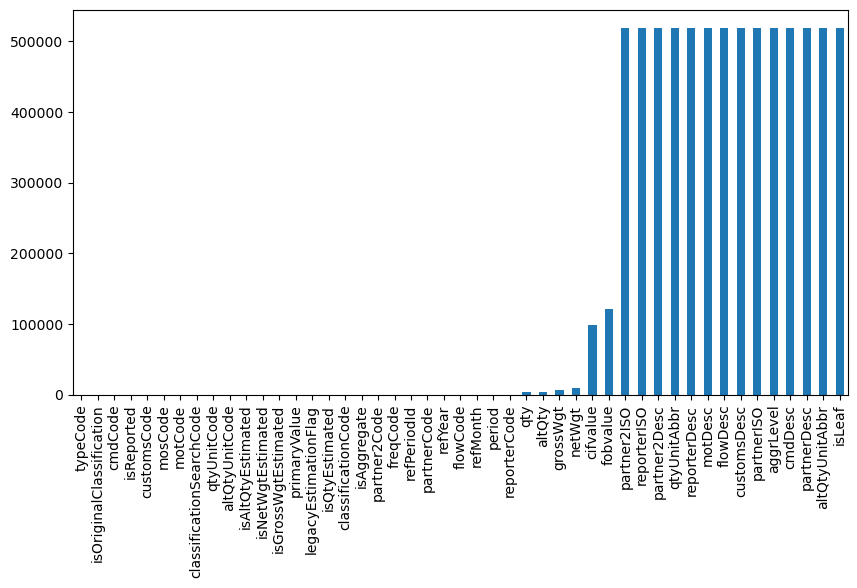

In [189]:
plt.figure(figsize=(10,5))
df_raw.isna().sum().sort_values().plot.bar()

In [190]:
cols_to_keep = ['period', 'refYear', 'refMonth', 'reporterCode', 
                'flowCode', 'partnerCode', 'classificationCode',
                'cmdCode', 'customsCode', 'motCode', 'qtyUnitCode', 'qty', 
                'isQtyEstimated', 'altQtyUnitCode', 'altQty', 'isAltQtyEstimated',
                'netWgt', 'isNetWgtEstimated', 'primaryValue', 'isAggregate']

explanations = {'period': 'YYYYMM of trade', 
                'refYear': 'year of trade', 
                'refMonth': 'month of trade', 
                'reporterCode': 'code of country who reported the trade', 
                'flowCode': 'code of trade flow, usually "M" for "Import" and "X" for "Export" ', 
                'partnerCode': 'code of country who is a counterparty in the trade reported by reporter country ', 
                'classificationCode': 'type of Harmonized System (HS) classification used for this trade. It has changed throughout the years',
                'cmdCode': 'code of commodity traded', 
                'customsCode': 'defines how the goods entered or left the economic territory', 
                'motCode': 'code of transport used to deliver the trade', 
                'qtyUnitCode': 'defines the unit of measurement of commodity traded', 
                'qty': 'quantity of commodity traded measured in a way specified in qtyUnitCode', 
                'isQtyEstimated': 'Is quantity Estimated - boolean', 
                'altQtyUnitCode': 'alternative unit of measurement of commodity traded', 
                'altQty': 'quantity of commodity traded measured in altQtyUnitCode units', 
                'isAltQtyEstimated': 'Is alternative quantity Estimated - boolean',
                'netWgt': 'net weight of commodity traded in kilograms', 
                'isNetWgtEstimated': 'Is quantity Estimated - boolean', 
                'primaryValue': 'value of trade in dollars',
                'isAggregate': 'is value aggregated - True or False'}


In [191]:
df = df_raw[cols_to_keep].copy()
df.shape

(518539, 20)

In [192]:
df[~((df.cmdCode == 271111) | (df.cmdCode == 271121))] #there are no mistakes - all trades are assigned to some type of gas

,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,qtyUnitCode,qty,isQtyEstimated,altQtyUnitCode,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,primaryValue,isAggregate


In [193]:
response = requests.get('https://comtradeapi.un.org/files/v1/app/wiki/ComtradePlus_DataItems.xlsx')
response.raise_for_status()
if response.status_code == 200:
    excel_codes = pd.ExcelFile(BytesIO(response.content))
print(excel_codes.sheet_names)       

# This dfs are needed to convert codes in some columns to human-readable words.

iso_codes = {'REF FLOWS': 'flwCode', 
             'REF MOT': 'motCode', 
             'REF QTY': 'qtyCode',
             'REF CUSTOMS': 'cstCode',
             'REF COUNTRIES': 'geoAreaCode'}

dfs_codes = {}
    
for sheet_name, col_name in iso_codes.items(): #creating 5 dfs with needed codes as indexes
    codes = pd.read_excel(excel_codes, sheet_name=sheet_name)
    codes.set_index(col_name, inplace=True)

    dfs_codes[col_name] = codes

dfs_codes.keys()

['COMTRADE+ COMPLETE', 'REF COUNTRIES', 'REF MOT', 'REF QTY', 'REF CUSTOMS', 'REF FLOWS', 'REF  MOS']


dict_keys(['flwCode', 'motCode', 'qtyCode', 'cstCode', 'geoAreaCode'])

In [194]:
def map_codes(series_codes: pd.Series, df: pd.DataFrame, column=None) -> pd.Series:
    """
    Function that maps given codes to needed descriptions. Returns series.
    Inputs: series_codes: series (column of df that needed to be decoded);
    df: dataframe used to locate codes by index to get the needed description;
    column: if needed, the column name can be specified to return values from this column. By default, the function returns everything.
    """
    if column:
        return series_codes.apply(lambda x: df.loc[x, column])
    else:
        return series_codes.apply(lambda x: df.loc[x])

In [195]:
to_map1 = {('reporter', 'reporterCode'): {'geoAreaDescription': dfs_codes['geoAreaCode']},
           ('partner', 'partnerCode'): {'geoAreaDescription': dfs_codes['geoAreaCode']},
           ('customs_type', 'customsCode'): {'cstDescription': dfs_codes['cstCode']},
           ('transport', 'motCode'): {'motName': dfs_codes['motCode']},
           ('flow_detail', 'flowCode'): {'flwDescription': dfs_codes['flwCode']},
           ('qty_type', 'qtyUnitCode'): {'qtyAbbr': dfs_codes['qtyCode']},
           ('alt_qty_type', 'qtyUnitCode'): {'qtyDescription': dfs_codes['qtyCode']}
           }

for (col_name, codes_col), col_and_df in to_map1.items():
    for source_col, source_df in col_and_df.items():
        df[col_name] = map_codes(series_codes=df[codes_col], 
                                 df=source_df, column=source_col)



In [196]:
df['type'] = df.cmdCode.apply(lambda x: 'liquefied' if x == 271111 else 'gaseous') #adding types of gas from codes
df['flow'] = df.flowCode.apply(lambda x: "Import" if "M" in x else "Export" if "X" in x else "None") # adding category of flow: Import/Export

df['period'] = pd.to_datetime(df['period'].astype(str), format = '%Y%m') # now we have it in date format to easily work with time series
for column in ['primaryValue', 'netWgt']: #everything to numeric
    df[column] = pd.to_numeric(df[column], errors='coerce') 

In [197]:
aggr_keys = {'parter': 'World', 'customs': 'TOTAL CPC', 
             'transport': 'Total Modes of Transport'} #These keys can be used in future to filter some types of aggregation

In [198]:
dfr = df[df.isAggregate == False].copy() #Now we have dataframe that contains only reports without any type of aggregation
dfr = dfr[(dfr.flow_detail == 'Export') | (dfr.flow_detail == 'Import')] 
# It appeared that sub-categories double actual values arificially, as for this df we want no aggregated data we filter this

dfr.drop('flow_detail', axis=1, inplace=True) #We have column "Flow" for this, no need to repeat yourself

"""
That was extremely difficult to find why the numbers does not match, but the reason is found - 
even if we no aggregation sub-categories like 'Foreign Import', 'Domestic Export' etc. can report the same trade 2 times.
Now we have clean like a tear, excellent dataframe to work with.
"""

"\nThat was extremely difficult to find why the numbers does not match, but the reason is found - \neven if we no aggregation sub-categories like 'Foreign Import', 'Domestic Export' etc. can report the same trade 2 times.\nNow we have clean like a tear, excellent dataframe to work with.\n"

In [199]:
dfr.sample(7).style

,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,qtyUnitCode,qty,isQtyEstimated,altQtyUnitCode,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,primaryValue,isAggregate,reporter,partner,customs_type,transport,qty_type,alt_qty_type,type,flow
300986,2020-05-01 00:00:00,2020,5,688,X,499,H5,271121,C03,3200,8,7440.000000,False,8,7440.000000,False,7440.000000,False,4388.000000,False,Serbia,Montenegro,Outright exportation,Road,kg,Weight in kilograms,gaseous,Export
494976,2025-02-01 00:00:00,2025,2,31,X,380,H6,271121,C03,9110,8,533313000.000000,False,12,730566000.000000,False,533313000.000000,False,375289092.970000,False,Azerbaijan,Italy,Outright exportation,Pipelines,kg,Weight in kilograms,gaseous,Export
331564,2021-03-01 00:00:00,2021,3,300,X,100,H5,271121,C00,9100,8,25533800.000000,False,18,1410.000000,False,25533800.000000,False,4908575.631000,False,Greece,Bulgaria,TOTAL CPC,Pipelines and cables,kg,Weight in kilograms,gaseous,Export
397526,2022-10-01 00:00:00,2022,10,376,M,842,H6,271121,C00,0,8,1473.888000,True,-1,0.000000,False,1473.888000,True,2000.000000,False,Israel,United States of America,TOTAL CPC,Total Modes of Transport,kg,Weight in kilograms,gaseous,Import
474737,2024-07-01 00:00:00,2024,7,764,X,116,H6,271111,C00,3000,8,103700.000000,False,8,103700.000000,False,103700.000000,False,70986.105000,False,Thailand,Cambodia,TOTAL CPC,Land,kg,Weight in kilograms,liquefied,Export
189635,2017-02-01 00:00:00,2017,2,764,X,699,H5,271121,C00,2100,8,5326.000000,False,8,5326.000000,False,5326.000000,False,31288.380000,False,Thailand,India,TOTAL CPC,Sea,kg,Weight in kilograms,gaseous,Export
280231,2019-11-01 00:00:00,2019,11,699,X,524,H5,271111,C00,0,8,5051500.000000,False,8,5051500.000000,False,5051500.000000,False,2785845.897000,False,India,Nepal,TOTAL CPC,Total Modes of Transport,kg,Weight in kilograms,liquefied,Export


In [200]:
for i in dfr.columns:
    print(f'column {i} has {dfr[i].isna().sum()} n/a rows ({dfr[i].isna().sum()*100/dfr.shape[0]}%).') #How many NaN values each column has

column period has 0 n/a rows (0.0%).
column refYear has 0 n/a rows (0.0%).
column refMonth has 0 n/a rows (0.0%).
column reporterCode has 0 n/a rows (0.0%).
column flowCode has 0 n/a rows (0.0%).
column partnerCode has 0 n/a rows (0.0%).
column classificationCode has 0 n/a rows (0.0%).
column cmdCode has 0 n/a rows (0.0%).
column customsCode has 0 n/a rows (0.0%).
column motCode has 0 n/a rows (0.0%).
column qtyUnitCode has 0 n/a rows (0.0%).
column qty has 3466 n/a rows (3.443000754956888%).
column isQtyEstimated has 0 n/a rows (0.0%).
column altQtyUnitCode has 0 n/a rows (0.0%).
column altQty has 3466 n/a rows (3.443000754956888%).
column isAltQtyEstimated has 0 n/a rows (0.0%).
column netWgt has 1557 n/a rows (1.5466682560495888%).
column isNetWgtEstimated has 0 n/a rows (0.0%).
column primaryValue has 0 n/a rows (0.0%).
column isAggregate has 0 n/a rows (0.0%).
column reporter has 0 n/a rows (0.0%).
column partner has 0 n/a rows (0.0%).
column customs_type has 0 n/a rows (0.0%).
co

In [201]:
dfr.to_parquet(os.path.join(folder_name, 'nat_gas_all_years_df'), engine='pyarrow', compression='snappy') 
#saving this df as a parquet file to then extract easily for analysis

After some analysis it appeared that reliable data comes only after 2010, before 2010 a lot of trades are missing.
I still save data from 2000 to 2009 in the case we need it but the main df will be with data from 2010 to 2025.

In [202]:
dfr_2010 = dfr[dfr.refYear >= 2010] 

In [205]:
dfr_2010.to_parquet(os.path.join(folder_name, 'nat_gas_trade_df'), engine='pyarrow', compression='snappy') 
#saving this df as a parquet file to then extract easily for analysis

# Part 2: filtering inconsistencies and creating a df for analysis of trades in kilograms.

In [206]:
nat_gas_codes = {271111: 'Natural gas, liquefied',
                 271121: 'Natural gas, gaseous'}

folder_name = 'nat_gas_2000-2025_Trade_data'

In [207]:
dfr = pd.read_parquet(os.path.join(folder_name, 'nat_gas_trade_df'), engine='pyarrow') #checking if we can extract this
print(dfr.shape)
dfr.sample(5).style

(91724, 28)


,period,refYear,refMonth,reporterCode,flowCode,partnerCode,classificationCode,cmdCode,customsCode,motCode,qtyUnitCode,qty,isQtyEstimated,altQtyUnitCode,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,primaryValue,isAggregate,reporter,partner,customs_type,transport,qty_type,alt_qty_type,type,flow
170059,2016-04-01 00:00:00,2016,4,32,M,226,H4,271111,C00,0,-1,0.000000,False,-1,0.000000,False,53551705.000000,False,13088759.430000,False,Argentina,Equatorial Guinea,TOTAL CPC,Total Modes of Transport,None,Not available or not specified or no quantity.,liquefied,Import
509006,2025-06-01 00:00:00,2025,6,842,X,414,H6,271111,C00,0,8,39630007.820000,True,12,121283.000000,False,39630007.820000,True,23663709.000000,False,United States of America,Kuwait,TOTAL CPC,Total Modes of Transport,kg,Weight in kilograms,liquefied,Export
491698,2024-12-01 00:00:00,2024,12,854,M,288,H6,271121,C00,3200,8,26000.000000,False,8,26000.000000,False,26000.000000,False,5798.987000,False,Burkina Faso,Ghana,TOTAL CPC,Road,kg,Weight in kilograms,gaseous,Import
67287,2010-04-01 00:00:00,2010,4,72,M,748,H1,271111,C00,3200,8,20000.000000,False,8,20000.000000,False,20000.000000,False,26357.695000,False,Botswana,Eswatini,TOTAL CPC,Road,kg,Weight in kilograms,liquefied,Import
141647,2014-11-01 00:00:00,2014,11,724,M,12,H4,271111,C01,2100,8,65024000.000000,False,18,3658.800000,False,65024000.000000,False,27828610.042000,False,Spain,Algeria,Clearance for home use,Sea,kg,Weight in kilograms,liquefied,Import


In [208]:
dfr.groupby(['refYear', 'flow', 'type'])[['primaryValue', 'netWgt']].agg('sum').tail(30)
#total import and export in dollars and in kg in billions for each form of gas

primaryValue        netWgt
refYear flow   type                                 
2018    Import gaseous    1.449023e+11  5.039653e+13
               liquefied  1.334037e+11  5.440320e+11
2019    Export gaseous    7.052576e+10  3.085320e+11
               liquefied  8.951154e+10  2.307891e+11
        Import gaseous    1.230652e+11  5.369498e+13
               liquefied  1.323101e+11  7.056005e+11
2020    Export gaseous    5.041017e+10  2.746012e+11
               liquefied  4.007184e+10  1.204072e+12
        Import gaseous    8.981311e+10  5.632651e+13
               liquefied  1.003032e+11  8.216043e+11
2021    Export gaseous    1.412068e+11  3.493979e+11
               liquefied  1.007133e+11  2.235062e+11
        Import gaseous    1.920918e+11  6.210057e+13
               liquefied  1.748342e+11  7.246524e+11
2022    Export gaseous    3.108296e+11  3.109447e+11
               liquefied  1.642181e+11  1.741268e+11
        Import gaseous    3.718893e+11  6.032037e+13
               liquefied  3.634238e+11  3.546971e+11
2023    Export gaseous    1.449323e+11  2.315073e+11
               liquefied  1.336496e+11  1.848876e+11
        Import gaseous    2.019757e+11  6.598795e+13
               liquefied  2.516039e+11  3.562686e+11
2024    Export gaseous    1.076077e+11  2.082611e+11
               liquefied  1.068541e+11  1.842337e+11
        Import gaseous    1.459781e+11  6.652340e+13
               liquefied  2.062010e+11  3.669874e+11
2025    Export gaseous    9.310529e+10  1.604500e+11
               liquefied  8.625172e+10  1.583214e+11
        Import gaseous    1.044884e+11  5.794974e+13
               liquefied  9.957010e+10  1.690311e+11

We see huge discrepancies in netWgt (traded gas measured in kg) in gaseous (and in liquified as appeared but smaller) form of gas starting from 2015 - netWgt needs filtering to use. Difference in export and import is expected - countries export goods with much lower prices then others import these goods. But difference in kg values is unreasonable.

In [209]:
dfr[(dfr.flow == 'Import') & (dfr.refYear >= 2020)].groupby('refYear')['netWgt'].nlargest(5)/10**9

refYear        
2020     322393    5450.1200
         309651    5236.2200
         312361    5149.4300
         305999    4845.9300
         318879    4628.6500
2021     349006    8114.3529
         345149    5773.7518
         351644    5484.8173
         331822    5458.9400
         342002    5443.7407
2022     383329    5376.6699
         390423    5314.2845
         387947    5301.1480
         380007    5189.6423
         394093    5026.8496
2023     434372    6105.3000
         430458    5960.8300
         441879    5794.1700
         437690    5713.5000
         426969    5705.4100
2024     466132    7144.8200
         476518    6012.3800
         479707    5977.8800
         473033    5799.6900
         469827    5597.9700
2025     507354    6313.0400
         512414    6282.2000
         510079    6076.5800
         514967    6067.2300
         504450    5832.0600
Name: netWgt, dtype: float64

In [210]:
bad_rows_g = dfr[ (dfr.cmdCode == 271121) & (dfr.flow == 'Import') & (dfr.refYear >= 2015)].groupby('refYear')['netWgt'].nlargest(7).index
bad_indexes_g = []
for i in range(len(bad_rows_g)):
    bad_indexes_g.append(bad_rows_g[i][1])      #getting indexes of these countries with crazy amounts of volume of trade in kg (7 just to see)

In [211]:
needed_cols = ['period', 'reporter', 'flow', 'partner', 'cmdCode', 'primaryValue', 'qty', 'qty_type', 'netWgt', 'altQty', 'alt_qty_type']
dfr.loc[bad_indexes_g, needed_cols].sample(10)

,period,reporter,flow,partner,cmdCode,primaryValue,qty,qty_type,netWgt,altQty,alt_qty_type
264315,2019-06-01,Mexico,Import,United States of America,271121,396455651.0,4.559280e+12,kg,4.559280e+12,4.559280e+12,Weight in kilograms
469827,2024-06-01,Mexico,Import,United States of America,271121,371541346.0,5.597970e+12,kg,5.597970e+12,5.597970e+12,Weight in kilograms
351644,2021-09-01,Mexico,Import,United States of America,271121,907764646.0,5.484817e+12,kg,5.484817e+12,5.484817e+12,Weight in kilograms
272958,2019-09-01,Mexico,Import,United States of America,271121,398911402.0,4.552610e+12,kg,4.552610e+12,4.552610e+12,Weight in kilograms
401029,2022-11-01,Mexico,Import,United States of America,271121,844137784.0,4.938460e+12,kg,4.938460e+12,4.938460e+12,Weight in kilograms
473033,2024-07-01,Mexico,Import,United States of America,271121,371823022.0,5.799690e+12,kg,5.799690e+12,5.799690e+12,Weight in kilograms
153183,2015-06-01,Mexico,Import,United States of America,271121,251090743.0,2.574400e+12,kg,2.574400e+12,2.574400e+12,Weight in kilograms
266849,2019-07-01,Mexico,Import,United States of America,271121,469999629.0,5.585570e+12,kg,5.585570e+12,5.585570e+12,Weight in kilograms
312361,2020-09-01,Mexico,Import,United States of America,271121,423412722.0,5.149430e+12,kg,5.149430e+12,5.149430e+12,Weight in kilograms
322393,2020-12-01,Mexico,Import,United States of America,271121,546210672.0,5.450120e+12,kg,5.450120e+12,5.450120e+12,Weight in kilograms


In [212]:
bad_rows_l = dfr[ (dfr.cmdCode == 271111) & (dfr.flow == 'Import') & (dfr.refYear >= 2015)].groupby('refYear')['netWgt'].nlargest(4).index
bad_indexes_l = []
for i in range(len(bad_rows_l)):
    bad_indexes_l.append(bad_rows_l[i][1])  #the same for liquified (it appeared there are also discrepancies - smaller than in gaseous so difficult to notice)

In [213]:
dfr.loc[bad_indexes_l, needed_cols].sample(10)

,period,reporter,flow,partner,cmdCode,primaryValue,qty,qty_type,netWgt,altQty,alt_qty_type
266848,2019-07-01,Mexico,Import,United States of America,271111,2.271719e+06,6.452370e+10,kg,6.452370e+10,6.452370e+10,Weight in kilograms
154722,2015-07-01,Mexico,Import,United States of America,271111,1.029712e+07,9.980890e+10,kg,9.980890e+10,9.980890e+10,Weight in kilograms
175893,2016-07-01,Mexico,Import,United States of America,271111,8.779755e+06,9.556980e+10,kg,9.556980e+10,9.556980e+10,Weight in kilograms
495634,2025-02-01,Japan,Import,Australia,271111,1.462435e+09,2.314310e+09,kg,2.314310e+09,2.314310e+06,Weight in kilograms
177795,2016-08-01,Mexico,Import,United States of America,271111,9.581312e+06,9.754310e+10,kg,9.754310e+10,9.754310e+10,Weight in kilograms
473599,2024-07-01,Netherlands,Import,United States of America,271111,4.640758e+08,5.120480e+09,kg,5.120480e+09,2.816300e+04,Weight in kilograms
309649,2020-08-01,Mexico,Import,United States of America,271111,5.301064e+06,6.575020e+10,kg,6.575020e+10,6.575020e+10,Weight in kilograms
161936,2015-11-01,Mexico,Import,United States of America,271111,8.870740e+06,9.531260e+10,kg,9.531260e+10,9.531260e+10,Weight in kilograms
272960,2019-09-01,Mexico,Import,United States of America,271111,4.689942e+06,7.666360e+10,kg,7.666360e+10,7.666360e+10,Weight in kilograms
465159,2024-05-01,China,Import,Australia,271111,1.464728e+09,2.636240e+09,kg,2.636240e+09,2.636240e+09,Weight in kilograms


In [214]:
dfr_kg = dfr[ ~( (dfr.refYear >= 2015) & 
                 (dfr.reporter == 'Mexico') & (dfr.flow == 'Import') & (dfr.partner == 'United States of America') )]
dfr_kg.shape, dfr.shape

((91409, 28), (91724, 28))

In [215]:
dfr_kg[dfr_kg.refYear >= 2021].groupby(['refYear', 'flow', 'cmdCode'])[['primaryValue', 'netWgt']].agg('sum')/10**9

primaryValue      netWgt
refYear flow   cmdCode                          
2021    Export 271111     100.713302  223.506232
               271121     141.206816  349.397938
        Import 271111     174.717343  333.746783
               271121     180.174352  399.662271
2022    Export 271111     164.218069  174.126765
               271121     310.829622  310.944718
        Import 271111     363.323064  354.438865
               271121     358.329844  288.721132
2023    Export 271111     133.649575  184.887573
               271121     144.932257  231.507317
        Import 271111     251.487759  355.978257
               271121     195.365725  274.899812
2024    Export 271111     106.854115  184.233667
               271121     107.607683  208.261053
        Import 271111     206.200084  365.258138
               271121     141.272699  266.788252
2025    Export 271111      86.251724  158.321401
               271121      93.105295  160.449964
        Import 271111      99.570104  169.031146
               271121      98.228916  165.963051

We see a common pattern: there is a mistake in registering value in kg of import of gaseous and liquified natural gas from USA to Mexico - so I created one more df without these trades and everything seems logical (it is likely that they write value in liters to value in kg since value in liters has the same value). However, trade value in dollars between countries corresponds to reality - I checked in public databases. So I will use for dollar analysis dfr (main df) and for analysis in kg I will use dfr_kg.

In [216]:
def plot_trades(column:str, measure: str, df=dfr):
    for i in range(2):
        for fl in ['Export', 'Import']:
            plt.figure(figsize=(10,3))
            (df[(df.flow == fl) & (df.cmdCode == list(nat_gas_codes.keys())[i] )].groupby('refYear')[column].sum()/10**9).plot.bar()
            plt.title(nat_gas_codes[ list(nat_gas_codes.keys())[i] ] + '; ' + str(column) + ', Total ' + str(fl))
            plt.xlabel('Years')
            plt.ylabel('Total ' +str(fl) + ', billions of ' +str(measure))
            plt.grid(True, alpha=0.5)

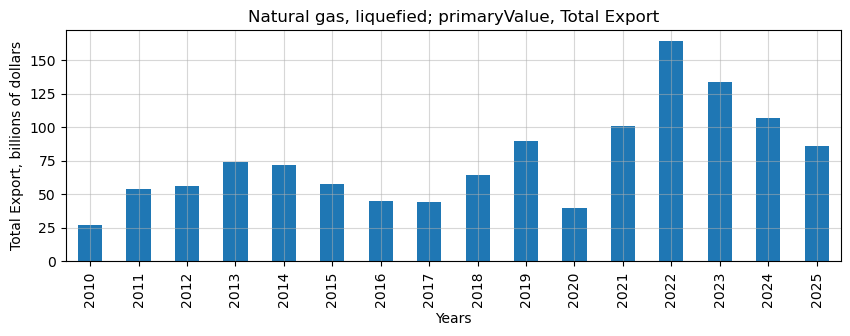

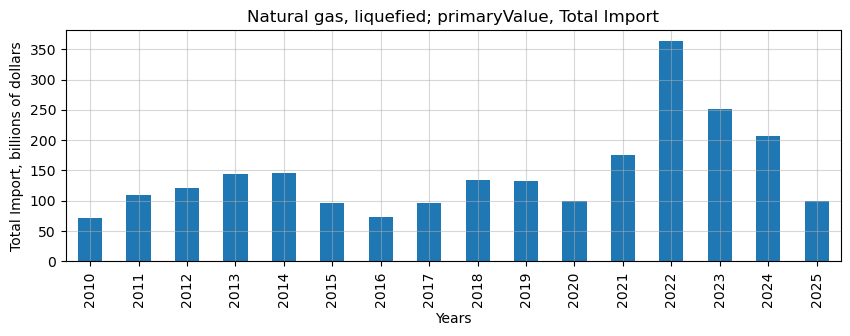

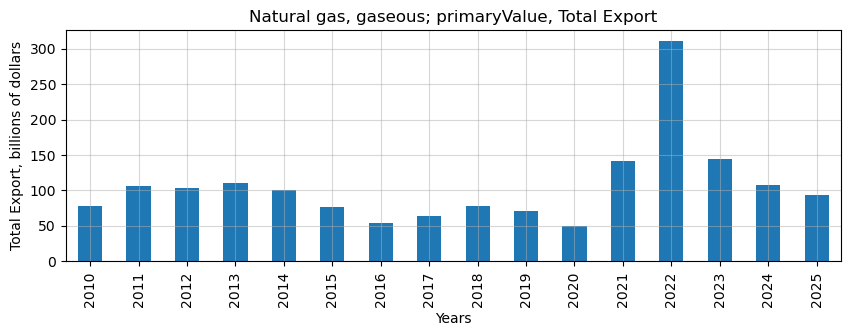

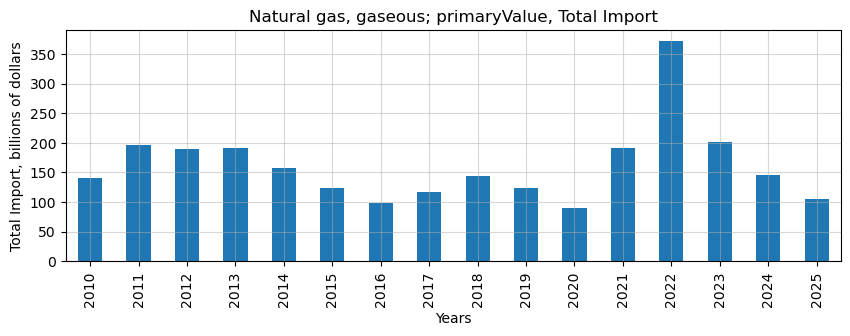

In [217]:
plot_trades(column='primaryValue', measure='dollars', df=dfr)

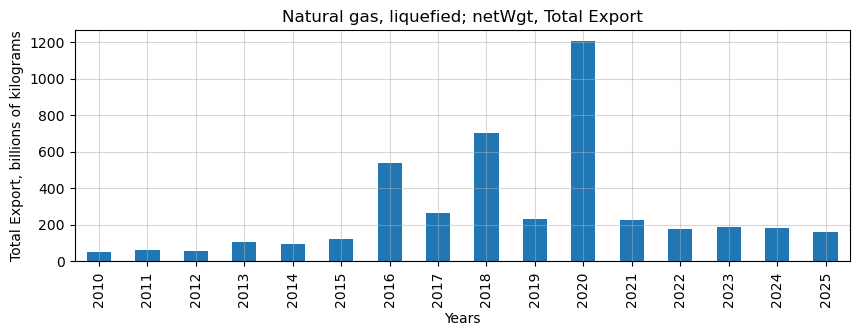

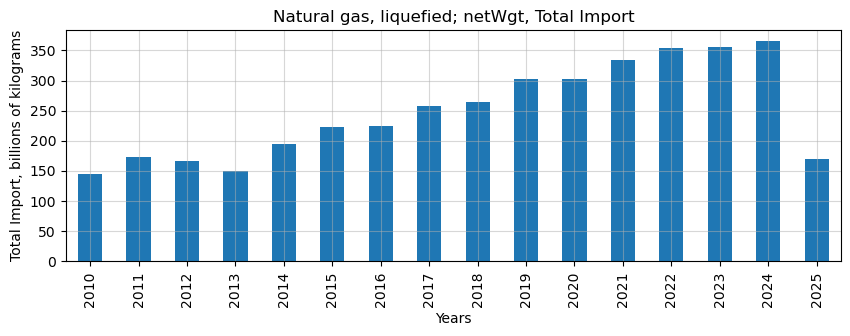

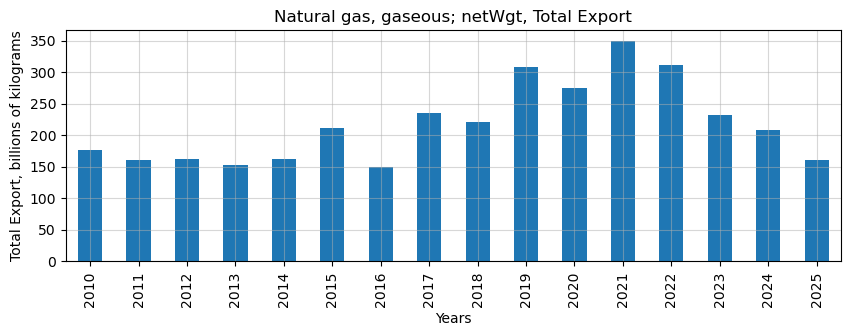

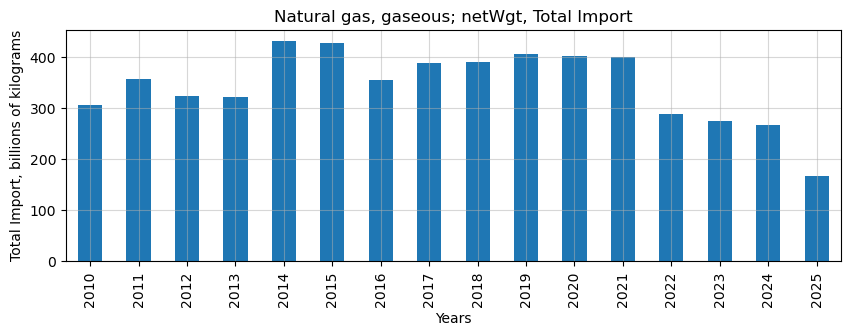

In [218]:
plot_trades(column='netWgt', measure = 'kilograms', df=dfr_kg)

However, there a still problems with values of export of natural liquified gas in 2016, 2018, and 2020.

In [219]:
dfr_kg[((dfr_kg.refYear == 2016) | (dfr_kg.refYear == 2018) | (dfr_kg.refYear == 2020)) 
       & (dfr_kg.flow == 'Export') & (dfr_kg.cmdCode == 271111)].groupby('refYear').netWgt.nlargest(6)

refYear        
2016     165274    2.943000e+11
         172185    1.466527e+10
         182887    1.367999e+10
         181203    1.245401e+10
         180097    1.224867e+10
         177852    1.084984e+10
2018     220556    6.060400e+10
         215327    4.699570e+10
         217869    3.809890e+10
         220526    3.153900e+10
         215324    2.994840e+10
         220530    2.880690e+10
2020     286770    2.863210e+10
         299954    2.608130e+10
         323595    2.422100e+10
         293402    2.310590e+10
         293414    2.276960e+10
         306758    2.203100e+10
Name: netWgt, dtype: float64

In [220]:
bad_rows = dfr_kg[((dfr_kg.refYear == 2016) | (dfr_kg.refYear == 2018) | (dfr_kg.refYear == 2020)) 
       & (dfr_kg.flow == 'Export') & (dfr_kg.cmdCode == 271111)].groupby('refYear').netWgt.nlargest(6).index
bad_indexes = []
for i in range(len(bad_rows)):
    bad_indexes.append(bad_rows[i][1])      #the same to get indexes of these trades

In [221]:
dfr_kg.loc[bad_indexes, needed_cols]

,period,reporter,flow,partner,cmdCode,primaryValue,qty,qty_type,netWgt,altQty,alt_qty_type
165274,2016-01-01,Myanmar,Export,China,271111,1.489659e+08,2.943000e+11,kg,2.943000e+11,2.943000e+08,Weight in kilograms
172185,2016-05-01,Mozambique,Export,South Africa,271111,2.974434e+07,0.000000e+00,None,1.466527e+10,0.000000e+00,Not available or not specified or no quantity.
182887,2016-11-01,Mozambique,Export,South Africa,271111,1.976806e+07,0.000000e+00,None,1.367999e+10,0.000000e+00,Not available or not specified or no quantity.
181203,2016-10-01,Mozambique,Export,South Africa,271111,1.804589e+07,0.000000e+00,None,1.245401e+10,0.000000e+00,Not available or not specified or no quantity.
180097,2016-09-01,Mozambique,Export,South Africa,271111,1.834781e+07,0.000000e+00,None,1.224867e+10,0.000000e+00,Not available or not specified or no quantity.
177852,2016-08-01,Mozambique,Export,South Africa,271111,1.681399e+07,0.000000e+00,None,1.084984e+10,0.000000e+00,Not available or not specified or no quantity.
220556,2018-03-01,Nigeria,Export,India,271111,1.475974e+08,6.060400e+10,kg,6.060400e+10,6.060400e+10,Weight in kilograms
215327,2018-01-01,Nigeria,Export,Spain,271111,1.212675e+08,4.699570e+10,kg,4.699570e+10,4.699570e+10,Weight in kilograms
217869,2018-02-01,Nigeria,Export,Portugal,271111,1.136139e+08,3.809890e+10,kg,3.809890e+10,3.809890e+10,Weight in kilograms
220526,2018-03-01,Nigeria,Export,Portugal,271111,9.318239e+07,3.153900e+10,kg,3.153900e+10,3.153900e+10,Weight in kilograms


We again see discrepancies - mostly with Nigeria, but other countries also appear. 
There should not be too huge difference between netWgt (weight in kg) and primaryValue (value in dollars) as price of gas has always been in a range about 0.1$-3$ per kg. Trades with other prices are barely possible: either these are artificial trades or there is a mistake in reports. Let us filter out all trades of unrealistic prices to make a dataset robust for analysis.

I will filter them from the df already without import of Mexico from USA because they confused volume with liters with values in kilograms - it is another type of mistake. These trades are mostly filtered by price but some smaller not, so it is more robust to work without them.

In [222]:
print(f'Original df shape: {dfr.shape}, df without Mexico-Usa trades: {dfr_kg.shape}')
dfr_kg = dfr_kg[dfr_kg.netWgt > 0] #to calculate price and not divide on 0 or have NaN.
print(f'DataFrame with prices shape: {dfr_kg.shape} \
      Lost rows: {dfr.shape[0] - dfr_kg.shape[0]} ({(dfr.shape[0] - dfr_kg.shape[0])*100/dfr.shape[0]:.4f}%)')

Original df shape: (91724, 28), df without Mexico-Usa trades: (91409, 28)
DataFrame with prices shape: (85390, 28)       Lost rows: 6334 (6.9055%)


In [223]:
dfr_kg['kg_price'] = dfr_kg.primaryValue / dfr_kg.netWgt

In [224]:
dfr_kg['kg_price'].describe()

count    8.539000e+04
mean     3.243606e+03
std      2.305029e+05
min      3.237318e-04
25%      3.394225e-01
50%      5.045405e-01
75%      7.743888e-01
max      2.611316e+07
Name: kg_price, dtype: float64

In [225]:
dfr_kg['kg_price'].sample(7)

210964      0.390078
428895      0.772234
131998      0.519414
354333      1.308060
163826      0.366965
88784       0.106250
401639    110.774969
Name: kg_price, dtype: float64

In [226]:
low_lim = dfr_kg.kg_price.quantile(0.01)
high_lim = dfr_kg.kg_price.quantile(0.99)
low_lim, high_lim

(np.float64(0.014874378147981529), np.float64(73.77410569117656))

In [227]:
dfr_kg = dfr_kg[(dfr_kg.kg_price > low_lim) & (dfr_kg.kg_price < high_lim)]

In [228]:
dfr_kg['kg_price'].describe()

count    83682.000000
mean         1.485420
std          5.327888
min          0.014876
25%          0.343604
50%          0.504540
75%          0.762919
max         73.755824
Name: kg_price, dtype: float64

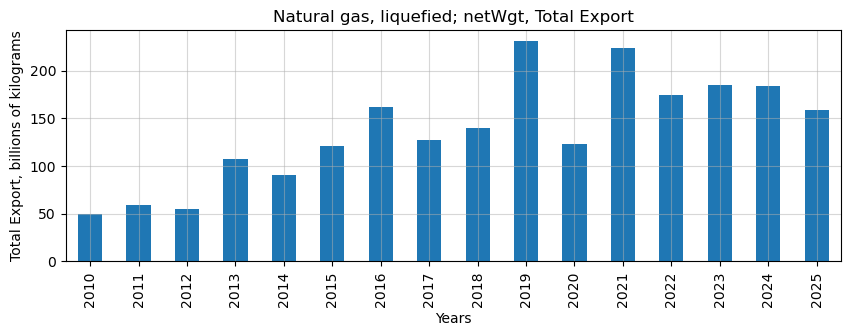

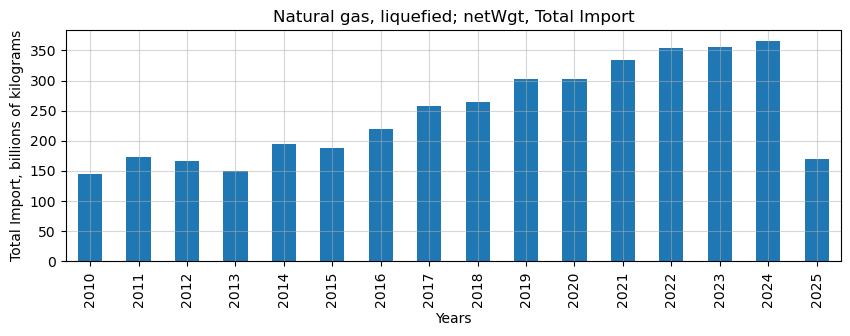

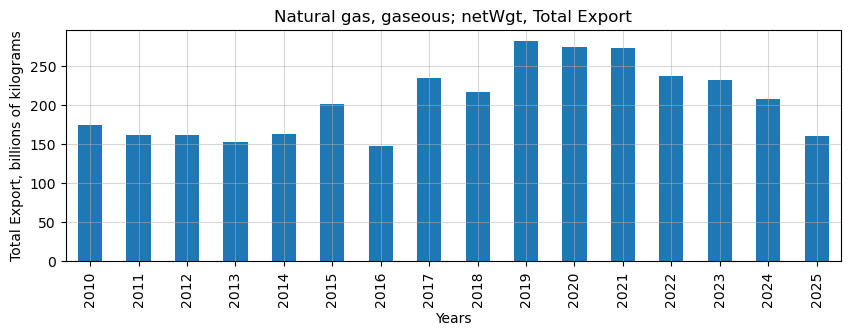

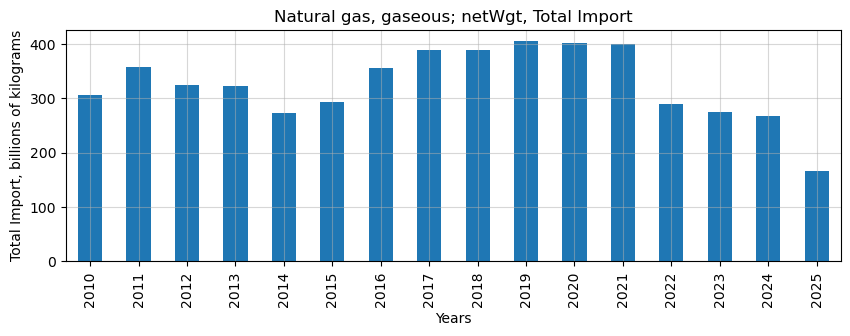

In [229]:
plot_trades(column='netWgt', measure = 'kilograms', df=dfr_kg)

In [230]:
dfr_kg.to_parquet(os.path.join(folder_name, 'nat_gas_trade_df_kg'), engine='pyarrow', compression='snappy')

print(f'In total we lost {dfr.shape[0] - dfr_kg.shape[0]} ({(dfr.shape[0] - dfr_kg.shape[0])*100/dfr.shape[0]:.4f}%) rows to have df to work with weights.')

In total we lost 8042 (8.7676%) rows to have df to work with weights.


Now we have df to analyse trade in kilograms to see the evolution of global trade without the influence of prices.
This df is a bit truncated, but it is still robust to compare with the df with dollar values. All huge outliers and mistakes are deleted.